# Tree Models

### Load libraries and data

In [4]:
import pandas as pd
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import matplotlib.pyplot as plt

In [5]:
# Load datasets
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
data_dictionary = pd.read_csv('data/data_dictionary.csv')
example_submission = pd.read_csv('data/sample_submission.csv')

print('Training Shape:',train.shape)
print('Test Shape:',test.shape)
print('Data Dictionary Shape:',data_dictionary.shape)
print('Example Submission Shape:',example_submission.shape)

Training Shape: (28800, 60)
Test Shape: (3, 58)
Data Dictionary Shape: (59, 4)
Example Submission Shape: (3, 2)


### Create Target Variable (Combined from efs and efs_time)

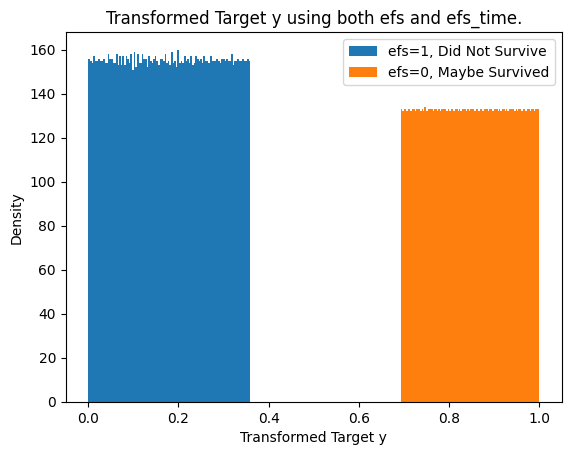

In [6]:
# Both targets efs and efs_time provide useful information. We will tranform these two targets into a single target to train our model with.
# Taken from https://www.kaggle.com/code/wjones3668/cibmtr-equity-in-post-hct-survival-predictions

train["y"] = train.efs_time.values
mx = train.loc[train.efs==1,"efs_time"].max()
mn = train.loc[train.efs==0,"efs_time"].min()
train.loc[train.efs==0,"y"] = train.loc[train.efs==0,"y"] + mx - mn
train.y = train.y.rank()
train.loc[train.efs==0,"y"] += len(train)//2
train.y = train.y / train.y.max()

plt.hist(train.loc[train.efs==1,"y"],bins=100,label="efs=1, Did Not Survive")
plt.hist(train.loc[train.efs==0,"y"],bins=100,label="efs=0, Maybe Survived")
plt.xlabel("Transformed Target y")
plt.ylabel("Density")
plt.title("Transformed Target y using both efs and efs_time.")
plt.legend()
plt.show()

### Train LGB Model